# WUS station density 

Computes the manuscript text stat *"1 station per ~1,200 km² in mountain regions of the Western U.S."*:
aggregate station count, total mountain-range area (GMBA v2.0, ranges containing at least one station,
Albers equal-area), area per station, and stations per 100 km², limited to the Western US.

In [1]:
from pathlib import Path

import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

from global_snowmelt_runoff_onset.results import save_result_table

In [2]:
# Same version-scoped inputs as 4_snow_pillow_representativeness.ipynb -- set VERSION
# to match the config used in 1_create_snow_pillow_comparison_dataset.ipynb.
VERSION = 'v10'
COMPARISON_DATA_DIR = Path('data/comparison_datasets') / VERSION

In [3]:
# our snow pillow station locations (the sites used in the comparison) -- identical
# source to 4_snow_pillow_representativeness.ipynb
max_swe_timing_ds = xr.open_zarr(COMPARISON_DATA_DIR / 'max_snow_pillow_swe_timing.zarr')
max_swe_timing_ds

<xarray.Dataset> Size: 968kB
Dimensions:                   (water_year: 11, station_id: 1234)
Coordinates:
  * water_year                (water_year) int64 88B 2015 2016 ... 2024 2025
  * station_id                (station_id) <U16 79kB '05AA817_AB_MSNT' ... 'W...
    client                    (station_id) <U6 30kB dask.array<chunksize=(1234,), meta=np.ndarray>
    elevation                 (station_id) float32 5kB dask.array<chunksize=(1234,), meta=np.ndarray>
    latitude                  (station_id) float64 10kB dask.array<chunksize=(1234,), meta=np.ndarray>
    longitude                 (station_id) float64 10kB dask.array<chunksize=(1234,), meta=np.ndarray>
    network                   (station_id) <U5 25kB dask.array<chunksize=(1234,), meta=np.ndarray>
    state                     (station_id) <U2 10kB dask.array<chunksize=(1234,), meta=np.ndarray>
    station_name              (station_id) <U41 202kB dask.array<chunksize=(1234,), meta=np.ndarray>
Data variables:
    100pct_of_max_SWE_timing  (water_year, station_id) float64 109kB dask.array<chunksize=(11, 1234), meta=np.ndarray>
    50pct_of_max_SWE_timing   (water_year, station_id) float64 109kB dask.array<chunksize=(11, 1234), meta=np.ndarray>
    90pct_of_max_SWE_timing   (water_year, station_id) float64 109kB dask.array<chunksize=(11, 1234), meta=np.ndarray>
    95pct_of_max_SWE_timing   (water_year, station_id) float64 109kB dask.array<chunksize=(11, 1234), meta=np.ndarray>
    99pct_of_max_SWE_timing   (water_year, station_id) float64 109kB dask.array<chunksize=(11, 1234), meta=np.ndarray>
    max_SWE_value             (water_year, station_id) float32 54kB dask.array<chunksize=(11, 1234), meta=np.ndarray>
Attributes:
    dataset_version:  v10

In [4]:
all_stations_gdf = gpd.GeoDataFrame(
    {'station_id': max_swe_timing_ds['station_id'].values},
    geometry=gpd.points_from_xy(max_swe_timing_ds['longitude'].values,
                                max_swe_timing_ds['latitude'].values),
    crs='EPSG:4326',
)
all_stations_gdf

,station_id,geometry
0,05AA817_AB_MSNT,POINT (-114.6 49.78333)
1,05BB803_AB_MSNT,POINT (-115.78333 51.08333)
2,05BF824_AB_MSNT,POINT (-115.27944 50.63139)
3,05BL811_AB_MSNT,POINT (-114.71 50.17389)
4,05BL812_AB_MSNT,POINT (-114.91308 50.48592)
...,...,...
1229,WHW,POINT (-119.65161 37.85944)
1230,WTM,POINT (-118.57167 36.34963)
1231,WTM_CA_MSNT,POINT (-118.572 36.348)
1232,WWC,POINT (-118.91478 37.03103)


In [5]:
url = (f"https://data.earthenv.org/mountains/standard/GMBA_Inventory_v2.0_standard_300.zip")
gmba_gdf = gpd.read_file("zip+" + url)
gmba_gdf

,GMBA_V2_ID,GMBA_V1_ID,MapName,WikiDataUR,MapUnit,Hier_Lvl,Feature,Area,Perimeter,Elev_Low,...,Name_ES,Name_FR,Name_PT,Name_RU,Name_ZH,LocalNames,ColorAll,ColorBasic,Color300,geometry
0,19102,NaN,Arctic Ocean,https://www.wikidata.org/wiki/Q788,Aggregated,1,Ocean,57205.24576,22872.03994,0.0,...,Océano Ártico,Océan Arctique,Oceano Ártico,Северный Ледовитый океан,北冰洋,Kadagatang Artiko (Norwegian),1,0,1,"MULTIPOLYGON (((-8.63071 70.96548, -8.62822 70..."
1,11134,3.04.01,Appalachian Mountains,https://www.wikidata.org/wiki/Q93332,Aggregated,2,Mountain range with well-recognized name,129875.02600,37431.11230,-159.0,...,Apalaches,Appalaches,Apalaches,Аппалачи,阿巴拉契亚山脉,NaN,4,0,1,"MULTIPOLYGON (((-85.78819 33.4368, -85.80703 3..."
2,12390,NaN,Cordillera Centroamericana,https://www.wikidata.org/wiki/Q5788379,Aggregated,2,Mountain range with well-recognized name,284121.62390,31599.87888,-1.0,...,Cordillera Centroamericana,NaN,NaN,NaN,NaN,NaN,1,0,2,"MULTIPOLYGON (((-77.41295 5.56954, -77.41741 5..."
3,12497,NaN,Caribbean Islands,https://www.wikidata.org/wiki/Q664609,Aggregated,2,Archipelago,61738.67557,10329.79926,-40.0,...,Caribe,Caraïbes,Caraíbas,Карибы,加勒比地区,NaN,4,0,4,"MULTIPOLYGON (((-61.05987 10.83557, -61.05311 ..."
4,14271,NaN,South Atlantic Islands,https://www.wikidata.org/wiki/Q1482804,Aggregated,2,Geographically-defined sub-range,5579.35771,1487.00483,-133.0,...,Océano Atlántico Sur,Océan Atlantique Sud,Atlântico Sul,Южная Атлантика,南大西洋,NaN,3,0,2,"MULTIPOLYGON (((3.39049 -54.395, 3.41145 -54.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286,11208,5.08.19,Central Range,NaN,Aggregated,6,Mountain range with well-recognized name,263615.62150,12354.30388,0.0,...,Cordillera Central,Chaîne Centrale,NaN,Центральный хребет Новой Гвинеи,巴布亞新幾內亞高地,NaN,6,0,4,"MULTIPOLYGON (((150.33845 -10.40741, 150.34297..."
287,12748,NaN,Borneo,https://www.wikidata.org/wiki/Q36117,Aggregated,6,Island,248480.11360,28667.97285,-48.0,...,Isla de Borneo,Bornéo,Bornéu,Калимантан,婆罗洲,Kalimantan (Acehnese); Nusa Kalimantan (Baline...,6,0,5,"MULTIPOLYGON (((114.97609 -3.51973, 114.9728 -..."
288,12756,NaN,Java,https://www.wikidata.org/wiki/Q3757,Aggregated,6,Island,42186.46494,6852.31987,0.0,...,Java,Java,Java,Ява,爪哇岛,Jawa (Acehnese); Jawa (Balinese); Jawa (Banjar...,1,0,4,"MULTIPOLYGON (((114.06353 -8.62899, 114.05197 ..."
289,18917,NaN,Sulawesi Archipelago,NaN,Aggregated,6,Archipelago,128619.86330,11614.45005,-16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,"MULTIPOLYGON (((120.73094 -7.09701, 120.71339 ..."


In [6]:
# only keep gmba ranges with stations, do a spatial join
gmba_with_stations_gdf = gpd.sjoin(gmba_gdf, all_stations_gdf, how="inner", predicate='intersects')
gmba_names = gmba_with_stations_gdf['MapName'].unique()
gmba_with_stations_gdf = gmba_gdf[gmba_gdf['MapName'].isin(gmba_names)]
gmba_with_stations_gdf

,GMBA_V2_ID,GMBA_V1_ID,MapName,WikiDataUR,MapUnit,Hier_Lvl,Feature,Area,Perimeter,Elev_Low,...,Name_ES,Name_FR,Name_PT,Name_RU,Name_ZH,LocalNames,ColorAll,ColorBasic,Color300,geometry
14,11400,5.02.11,Himalaya,https://www.wikidata.org/wiki/Q5451,Aggregated,3,Mountain range with well-recognized name,557695.62380,14805.84001,90.0,...,Himalaya,Himalaya,Himalaias,Гималаи,喜马拉雅山脉,হিমালয় (Assamese); हिमालय (Awadhi); হিমালয় প...,3,0,1,"MULTIPOLYGON (((87.87849 26.69124, 87.87734 26..."
97,11113,3.01.02,Alaska Range,https://www.wikidata.org/wiki/Q156684,Aggregated,4,Mountain range with well-recognized name,78722.45882,11358.71801,29.0,...,Cordillera de Alaska,Chaîne d'Alaska,Cordilheira do Alasca,Аляскинский хребет,阿拉斯加山脈,NaN,5,0,3,"MULTIPOLYGON (((-151.15431 61.76102, -151.1466..."
108,11202,3.06.20,Cascade Range,https://www.wikidata.org/wiki/Q4558,Aggregated,4,Mountain range with well-recognized name,114472.12800,9245.37592,0.0,...,Cordillera de Las Cascadas,Chaîne des Cascades,Cordilheira das Cascatas,Каскадные горы,喀斯喀特山脉,NaN,3,0,1,"MULTIPOLYGON (((-122.09429 40.23728, -122.0958..."
110,11234,3.06.01,Coast Mountains,https://www.wikidata.org/wiki/Q920070,Aggregated,4,Mountain range with well-recognized name,270074.62840,29830.55715,-196.0,...,Montañas Costeras,Chaîne Côtière,Montanhas Costeiras,Береговой хребет,海岸山脈,NaN,4,0,2,"MULTIPOLYGON (((-122.67953 48.54528, -122.6870..."
125,11591,3.02.03,Mackenzie Mountains,https://www.wikidata.org/wiki/Q1817102,Aggregated,4,Mountain range with well-recognized name,221595.42010,22369.83281,80.0,...,NaN,Monts Mackenzie,NaN,Маккензи,马更些山脉,NaN,1,0,1,"MULTIPOLYGON (((-126.02392 59.70501, -126.0291..."
129,11688,3.06.02,Olympic Mountains,https://www.wikidata.org/wiki/Q255079,Aggregated,4,Mountain range with well-recognized name,8403.68133,849.33345,0.0,...,NaN,Montagnes Olympiques,NaN,Олимпик,奥林匹克山脉,NaN,3,0,3,"MULTIPOLYGON (((-124.35404 47.67685, -124.3474..."
134,11789,3.01.17,Saint Elias Mountains,https://www.wikidata.org/wiki/Q48719,Aggregated,4,Mountain range with well-recognized name,64085.51250,8177.93775,0.0,...,Montañas San Elías,Chaîne Saint-Élie,Montanhas de Santo Elias,Горы Святого Ильи,聖埃利亞斯山脈,NaN,1,0,4,"MULTIPOLYGON (((-136.03243 58.30819, -136.0308..."
142,11928,3.03.87,Sierra Nevada,https://www.wikidata.org/wiki/Q26777,Aggregated,4,Mountain range with well-recognized name,62250.92447,4084.76608,31.0,...,Sierra Nevada,NaN,Serra Nevada,Сьерра-Невада,內華達山脈,NaN,4,0,2,"MULTIPOLYGON (((-119.66785 37.03245, -119.6711..."
154,12104,NaN,Colorado Plateau,https://www.wikidata.org/wiki/Q925906,Aggregated,4,Highland or plateau,113459.47490,24145.10731,369.0,...,Meseta del Colorado,Plateau du Colorado,Planalto do Colorado,Колорадо,科羅拉多高原,NaN,2,0,3,"MULTIPOLYGON (((-109.3208 33.79229, -109.30929..."
160,12199,NaN,Canadian Rockies,https://www.wikidata.org/wiki/Q1353201,Aggregated,4,Mountain range with well-recognized name,77958.12361,4506.70807,653.0,...,Montañas Rocosas de Canadá,Rocheuses Canadiennes,Montanhas Rochosas Canadianas,Канадские Скалистые горы,加拿大洛磯山,NaN,4,0,5,"MULTIPOLYGON (((-114.23335 49.70293, -114.2204..."


<Axes: >

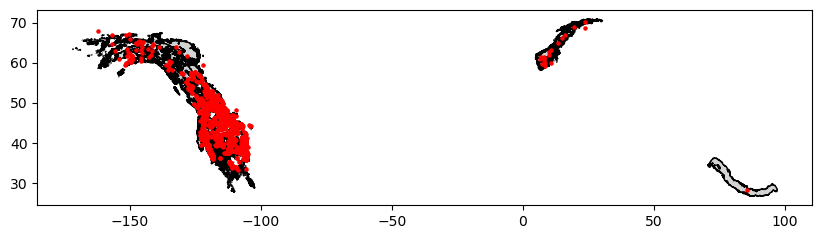

In [7]:
f,ax=plt.subplots(figsize=(10,10))
gmba_with_stations_gdf.plot(ax=ax, color='lightgrey', edgecolor='black')
all_stations_gdf.plot(ax=ax, color='red', markersize=5)

In [8]:
# limit to the Western US: the shared inventory also has BC / Norway / Nepal stations,
# so bound by the WUS box (same rect the GMBA ranges are clipped to below), not just < 49N
WUS_stations_gdf = all_stations_gdf.cx[-125:-66, 24:49]
WUS_stations_gdf

,station_id,geometry
11,1000_OR_SNTL,POINT (-122.16518 42.87007)
14,1005_CO_SNTL,POINT (-105.37322 37.6148)
15,1006_NV_SNTL,POINT (-116.8647 40.3572)
16,1008_MT_SNTL,POINT (-110.8536 46.91348)
17,1009_MT_SNTL,POINT (-110.90198 46.9269)
...,...,...
1229,WHW,POINT (-119.65161 37.85944)
1230,WTM,POINT (-118.57167 36.34963)
1231,WTM_CA_MSNT,POINT (-118.572 36.348)
1232,WWC,POINT (-118.91478 37.03103)


In [9]:
WUS_gmba_with_stations_gdf = gmba_with_stations_gdf.clip_by_rect(-125,24,-66,49)
WUS_gmba_with_stations_gdf

14                              GEOMETRYCOLLECTION EMPTY
97                              GEOMETRYCOLLECTION EMPTY
108    MULTIPOLYGON (((-122.09429 40.23728, -122.0958...
110    MULTIPOLYGON (((-122.67953 48.54528, -122.6870...
125                             GEOMETRYCOLLECTION EMPTY
129    MULTIPOLYGON (((-124.35404 47.67685, -124.3474...
134                             GEOMETRYCOLLECTION EMPTY
142    MULTIPOLYGON (((-119.66785 37.03245, -119.6711...
154    MULTIPOLYGON (((-109.3208 33.79229, -109.30929...
160                             GEOMETRYCOLLECTION EMPTY
161    MULTIPOLYGON (((-105.07216 35.30089, -105.0865...
164    MULTIPOLYGON (((-114.82993 33.70856, -114.8082...
166    MULTIPOLYGON (((-117.24474 47.60306, -117.2396...
167    MULTIPOLYGON (((-123.60179 48.81723, -123.6008...
168    POLYGON ((-123.84896 42.71551, -123.84275 42.7...
173    MULTIPOLYGON (((-119.86958 43.2826, -119.87086...
174                             GEOMETRYCOLLECTION EMPTY
190    MULTIPOLYGON (((-123.699

<Axes: >

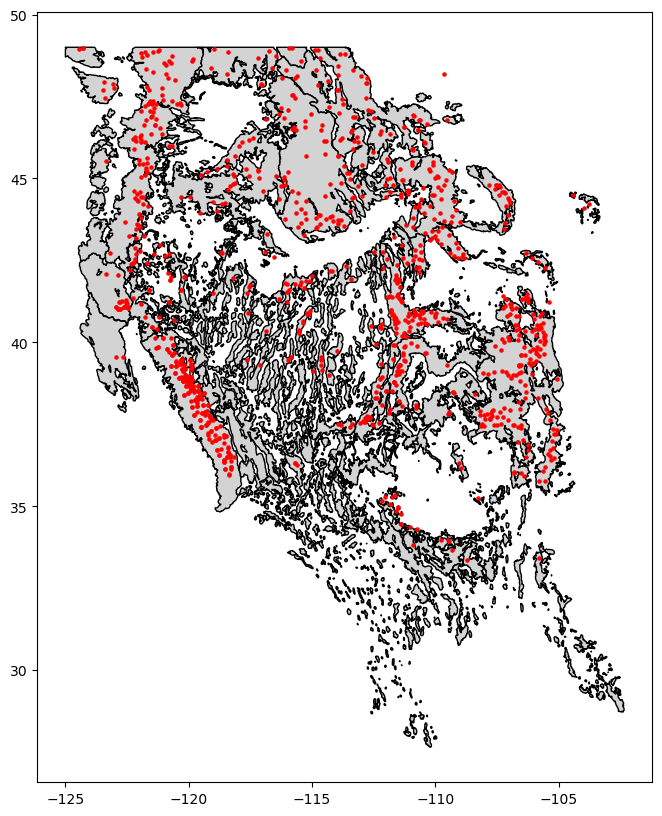

In [10]:
f,ax=plt.subplots(figsize=(10,10))
WUS_gmba_with_stations_gdf.plot(ax=ax, color='lightgrey', edgecolor='black')
WUS_stations_gdf.plot(ax=ax, color='red', markersize=5)

In [11]:
# calculate total area
WUS_gmba_with_stations_aea_gdf = WUS_gmba_with_stations_gdf.to_crs(epsg=5070)  # Albers Equal Area# calculate total area
WUS_gmba_with_stations_aea_gdf

14                              GEOMETRYCOLLECTION EMPTY
97                              GEOMETRYCOLLECTION EMPTY
108    MULTIPOLYGON (((-2173315.879 2213826.568, -217...
110    MULTIPOLYGON (((-1964592.293 3115824.93, -1965...
125                             GEOMETRYCOLLECTION EMPTY
129    MULTIPOLYGON (((-2112468.641 3060001.429, -211...
134                             GEOMETRYCOLLECTION EMPTY
142    MULTIPOLYGON (((-2064171.468 1812767.645, -206...
154    MULTIPOLYGON (((-1220682.062 1277457.935, -121...
160                             GEOMETRYCOLLECTION EMPTY
161    MULTIPOLYGON (((-816729.762 1399484.89, -81815...
164    MULTIPOLYGON (((-1721723.839 1353544.257, -172...
166    MULTIPOLYGON (((-1594990.341 2913385.06, -1594...
167    MULTIPOLYGON (((-2022052.062 3163867.717, -202...
168    POLYGON ((-2235269.368 2520795.447, -2234921.1...
173    MULTIPOLYGON (((-1907450.352 2495079.786, -190...
174                             GEOMETRYCOLLECTION EMPTY
190    MULTIPOLYGON (((-2188821

In [12]:
num_stations = len(WUS_stations_gdf)
num_stations

994

In [13]:
total_area_km2 = WUS_gmba_with_stations_aea_gdf.area.sum()/1e6
total_area_km2

np.float64(1191380.5979987583)

In [14]:
area_per_station_km2 = total_area_km2 / num_stations
area_per_station_km2

np.float64(1198.5720301798374)

In [15]:
# calculate station density per 100 km^2
station_density_per_100km2 = num_stations / (total_area_km2 / 100)
station_density_per_100km2

np.float64(0.0834326160481116)

In [16]:
summary_df = pd.DataFrame([{
    'n_stations': num_stations,
    'total_mountain_area_km2': round(total_area_km2, 1),
    'area_per_station_km2': round(area_per_station_km2, 1),
    'stations_per_100km2': round(station_density_per_100km2, 4),
    'station_source': f'max_snow_pillow_swe_timing.zarr ({VERSION}) usable stations, WUS box -125..-66E / 24..49N',
    'range_source': 'GMBA Inventory v2.0 standard, ranges containing >=1 station, Albers EPSG:5070 areas',
}])
save_result_table(summary_df, 'station_density', version=VERSION)
print(f"1 station per ~{area_per_station_km2:,.0f} km^2 of WUS mountain area (manuscript Sect. 5.1)")
summary_df

wrote 1 row(s) -> results/v10/station_density.csv
1 station per ~1,199 km^2 of WUS mountain area (manuscript Sect. 5.1)


,n_stations,total_mountain_area_km2,area_per_station_km2,stations_per_100km2,station_source,range_source
0,994,1191380.6,1198.6,0.0834,max_snow_pillow_swe_timing.zarr (v10) usable s...,"GMBA Inventory v2.0 standard, ranges containin..."
